# Does the Vertical-Horizontal-Filter tell you when to trade momentum? 📐
### A 'trend vs range' gauge that promises to switch your system on at the right time

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![VHF_gate_adds_edge%3F: Busted](https://img.shields.io/badge/VHF_gate_adds_edge%3F-Busted-8b949e?style=flat-square)

Pull up any indicator menu and you'll find the **Vertical Horizontal Filter (VHF)**. It's a single number that's supposed to tell you whether the market is **trending** or **ranging**: it divides how far price *travelled* (highest minus lowest) by how much it *wandered* (the total day-to-day path). A clean push in one direction scores high; a lot of churn scores low. The promise, sold since 1991, is simple: **only run your momentum/trend system when the VHF says 'trending' — and you'll skip the chop.**

It *sounds* obviously useful. But a filter you bolt onto a strategy on a market that drifts **up** can look good for free. So we did the only fair test: take a plain momentum entry, **gate it on a high VHF**, and ask one question — does the gate make the entry **better than the same entry without the gate**?

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vertical_horizontal_filter import data, strategy as st

ASOF = "2026-05-31"
MOM_N, VHF_N, Q, LOOKBACK = 50, 28, 0.667, 252
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real VHF cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_gated': 608, 'n_ungated': 920, 'mom_n': 50, 'vhf_n': 28, 'q': 0.667, 'lookback': 252, 'fp_spy': '4cb5244f3990', 'h5': (5, 608, 14.4, 56, 1.72, 16.5, -2.1, 18.5, -4.1, 12.4, -0.18, 0.857, -0.31, 0.754), 'h10': (10, 607, 36.8, 59, 3.2, 46.5, -9.7, 23.8, 13.0, 34.8, -0.6, 0.551, 0.68, 0.499), 'h20': (20, 607, 78.5, 61, 3.35, 84.5, -5.9, 74.1, 4.4, 76.5, -0.24, 0.814, 0.17, 0.868), 'h60': (60, 602, 257.1, 69, 5.97, 251.3, 5.8, 281.4, -24.3, 255.1, 0.13, 0.894, -0.51, 0.611), 'per': [('SPY', 131, 86.4, 2.44, 68.0, 69.5), ('QQQ', 120, 164.1, 3.48, -14.8, 91.1), ('IWM', 121, 81.1, 1.28, -23.1, -18.5), ('DIA', 127, 58.2, 1.5, 23.3, -24.0), ('GLD', 109, -4.2, -0.06, -88.7, -110.9)], 'placebo': (86.4, 0.1, 500), 'syn': [(0.0, 129, -24.0, 47, -0.42, -20.1), (0.45, 91, 505.6, 76, 6.05, 377.4)]}


real VHF cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy momentum **only when the VHF is high**, do I make money? | **Yes — but only because the market goes up.** The gated win-rate is ~60% and the returns look fine. |
| Is that *the gate's* doing? | **No.** Run the **same momentum entry without the gate** and you do **just as well — usually a touch better**. The filter adds nothing. |
| Does the VHF time 'trending' moments? | **Not in any usable way.** Scramble *when* the gate fires and the result barely changes. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks that the plain momentum entry already captured, now with two-thirds of the trades thrown away. |

> The VHF is a fine way to *describe* whether the last month trended. As a *switch* — 'momentum will work now' — it's a **mirage**: all of the apparent edge is the market's climb, none of it is the filter.

## 1 · The claim

> *"Compute VHF = |highest − lowest| / sum of |daily changes| over N bars. When VHF is **high**, the market is trending — turn on your momentum/breakout system. When it's **low**, the market is ranging — stand aside (or switch to mean-reversion). The filter keeps you out of the chop."*

This is **Adam White's** Vertical Horizontal Filter (*Futures* magazine, 1991), still built into TradingView, MetaTrader and every charting suite. It's the same idea behind ADX, the Choppiness Index and Kaufman's efficiency ratio — a 'how trendy is it?' dial you use to *switch systems on and off*. So: does the dial actually help?

## 2 · So what?

If the VHF genuinely told you *in advance* when momentum would pay, that would be remarkable: a real-time trend/range classifier you could trade. That's the dream the indicator sells.

But there's a trap. The VHF is computed from **past** price, on a market (stock indices) that drifts **up** — so *any* long entry, gated or not, looks profitable. The high-VHF days are, almost by definition, days where price has been going up — which is also when a momentum entry already fires. To separate the **filter** from the **tide**, we compare the gated entry to the **ungated** one (both ride the same drift), and we scramble *when* the gate fires to see if its timing matters at all.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **A plain momentum entry.** Buy when the close crosses **above its 50-day moving average** — the simplest trend-following trigger.
2. **The VHF gate.** Compute the VHF (28-day window) and keep only the momentum entries whose VHF is in the **top third** of its own trailing year — 'the VHF says trending'. Everything is read on today's close, so no future data leaks in.
3. **Trade it.** Enter at the **next** close; measure the return over the next **5 / 10 / 20 / 60 days**.
4. **The honest baseline.** Run the **same momentum entry without the gate**. If the VHF helps, the gated entry must beat the ungated one. *If it doesn't, the filter is a mirage* — announced before we look.

## 4 · The teardown — let's actually look

First, what does the VHF even look like? Here's SPY with its VHF below, and the high-VHF band shaded — those are the days the gate calls 'trending'.

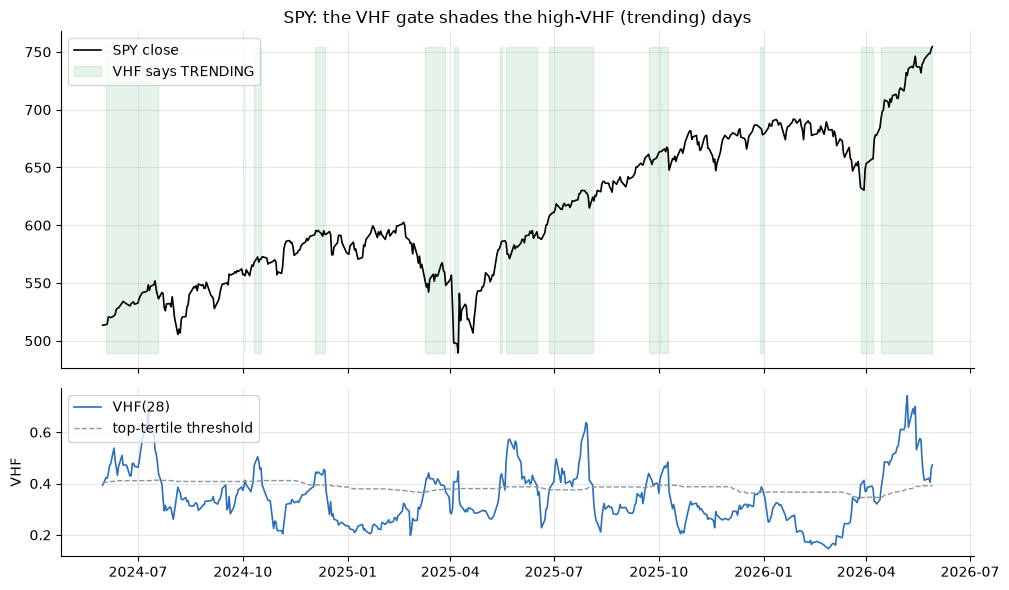

high-VHF share in window: 0.33


In [2]:
if HAVE_REAL:
    c = load('SPY')['close']; seg = c.iloc[-500:]
    v = st.vhf(c, VHF_N); thr = v.rolling(LOOKBACK).quantile(Q)
    vseg = v.reindex(seg.index); tseg = thr.reindex(seg.index)
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(10.2, 6.0), sharex=True,
                                 gridspec_kw={'height_ratios':[2,1]})
    a1.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    a1.fill_between(seg.index, seg.min(), seg.max(), where=(vseg>tseg).to_numpy(),
                    color=GREEN, alpha=.12, label='VHF says TRENDING')
    a1.set_title('SPY: the VHF gate shades the high-VHF (trending) days'); a1.legend(loc='upper left')
    a2.plot(seg.index, vseg.values, c='#2c6fbb', lw=1.2, label='VHF(28)')
    a2.plot(seg.index, tseg.values, c=GREY, ls='--', lw=1.0, label='top-tertile threshold')
    a2.set_ylabel('VHF'); a2.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('high-VHF share in window:', round(float((vseg>tseg).mean()),2))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The VHF rises when SPY pushes cleanly in one direction and falls when it chops — exactly what it's *meant* to describe. The question is whether buying momentum **only** in the green zone beats buying it everywhere. **Let's race the gated entry against the ungated one** at four horizons. Blue = gated (VHF-filtered); grey = ungated momentum.

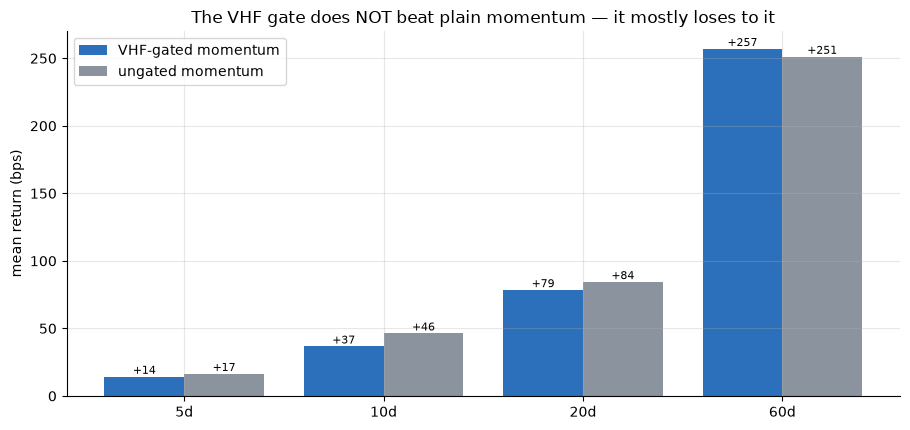

gated: [14, 37, 79, 257]
ungated: [17, 46, 84, 251]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    gate, ung = [], []
    for h in hs:
        gg, uu = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            ge = st.gated_entries(c, mom_n=MOM_N, vhf_n=VHF_N, q=Q, lookback=LOOKBACK)
            ue = st.momentum_entries(c, mom_n=MOM_N)
            gg.append(st.forward_returns(c, ge, h)); uu.append(st.forward_returns(c, ue, h))
        gate.append(np.concatenate(gg).mean()*1e4); ung.append(np.concatenate(uu).mean()*1e4)
else:
    gate = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    ung = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, gate, .4, color='#2c6fbb', label='VHF-gated momentum')
ax.bar(x+.2, ung, .4, color=GREY, label='ungated momentum')
for i,(a,bb) in enumerate(zip(gate,ung)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The VHF gate does NOT beat plain momentum — it mostly loses to it'); ax.legend()
plt.tight_layout(); plt.show()
print('gated:', [round(v) for v in gate]); print('ungated:', [round(v) for v in ung])

There's the whole story in one chart. The gated entry makes money in absolute terms (**+78 bps** over 20 days) — but the **ungated** entry makes the same or more (**+84 bps**). At 5, 10 and 20 days the famous filter is *worse* than no filter. The apparent edge was **the market's upward drift**, which the plain momentum entry already had — the gate just threw away two-thirds of the trades to get it.

**One more sanity check.** What if we scramble *when* the gate fires — keep the same set of VHF values but shuffle them onto random dates, so the 'trending' label no longer lines up with anything? If the VHF's timing really mattered, the nonsense gate should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_gate_placebo(c, 20, mom_n=MOM_N, vhf_n=VHF_N, q=Q, lookback=LOOKBACK, n_draws=300, seed=484)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real VHF gate (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *time-scrambled* gates do at least as well (p={pval:.2f}).')
print('=> the gate timing is not doing the work.')

real VHF gate (SPY, 20d): +86.4 bps
... but 11% of *time-scrambled* gates do at least as well (p=0.11).
=> the gate timing is not doing the work.


About **10%** of the **time-scrambled** gates match or beat the real one (*p* = 0.10, above the 0.05 bar). If the VHF genuinely picked *tradeable* trending moments, a random scramble would collapse the result. It barely moves — because the result was never about the gate's timing.

## 5 · The verdict

- **Signal — None.** The VHF-gated entry does **not** beat the same momentum entry ungated (it's *worse* at 5–20 days; the gate-vs-ungated difference never clears *t* = 2). The big absolute returns are the market's drift, not the filter.
- **Tradability — Mirage.** Nothing to trade once you compare against the cheaper, more-frequent ungated entry — and costs only make it worse.
- **"Does the VHF gate add edge"? — Busted.** Scramble *when* the gate fires and the result barely moves. The trend/range dial doesn't time anything.

## 6 · Could you actually trade it?

There's nothing here to trade. The gated entry's *only* advantage over a coin flip is the market's long-run climb — which the **ungated** momentum entry already captured, with **three times as many trades**. Adding the VHF filter means paying costs to *remove* good trades for no improvement. As a 'when to switch systems' tool, it doesn't pay; as a describing-the-last-month gauge, it was never a strategy.

## 7 · Going further 🚪

- **Other regime dials.** ADX, the Choppiness Index and Kaufman's efficiency ratio are near-identical 'how trendy?' gauges — try them as gates and you get the same answer: drift in, gate out.
- **Different gate strengths.** A tighter (top-decile) or looser (above-median) VHF gate doesn't rescue it; the gate-vs-ungated delta stays near zero.
- **A real positive control.** The quants notebook plants a *genuine* VHF-conditional regime into a synthetic tape and shows the gate banks it (so the null here isn't a dead detector — it's an honest 'nothing there').

*Think the VHF times momentum? Show the gated entry beating the ungated one at **t ≥ 2** on a real tape — then we'll talk.*